## Analysis on Play Store Review

### Import Libraries, Declare Trivial Options

In [1]:
import kagglehub
import os
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import yeojohnson
from sklearn.feature_extraction.text import TfidfVectorizer
from cuml.cluster import KMeans
from dask_ml.cluster import SpectralClustering

from util import to_darr
from calc import get_svd, cluster_iterated, cluster_aggregated

sns.set_theme(
  style='white', 
  font_scale=.7,
  palette='Set2',
  font='Monospace'
)

asthetic_constraint=dict(
  alpha=.9,
)

pyarrow_constraint=dict(
  compression='zstd',
  compression_level=9
)

## Sanitise the Dataset

### Download

In [3]:
path=kagglehub.dataset_download("shivkumarganesh/tinder-google-play-store-review")
# Or, path='~/.cache/kagglehub/datasets/shivkumarganesh/tinder-google-play-store-review/versions/158'

os.chdir(path)

data=pd.read_csv(os.path.join(path, os.listdir()[0]))

data.info(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641303 entries, 0 to 641302
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              641303 non-null  object
 1   userName              641303 non-null  object
 2   userImage             641303 non-null  object
 3   content               639970 non-null  object
 4   score                 641303 non-null  int64 
 5   thumbsUpCount         641303 non-null  int64 
 6   reviewCreatedVersion  509929 non-null  object
 7   at                    641303 non-null  object
 8   replyContent          59332 non-null   object
 9   repliedAt             59332 non-null   object
 10  appVersion            509929 non-null  object
dtypes: int64(2), object(9)
memory usage: 53.8+ MB


In [4]:
data.sample(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
340100,f85a2941-7af0-47e3-8477-18f2ba9ee31c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is perfact app.for dating,5,0,5.3.5,2019-02-21 18:52:47,NaN,NaN,5.3.5
398660,e4410a84-e839-49f3-a69a-960b60cda190,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Not very good app at all,1,0,7.4.0,2018-05-08 08:09:32,NaN,NaN,7.4.0
269693,8e55af81-0630-49ec-afc8-6d8769cbc1ad,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,For the biggest dating app i didnt expect it t...,2,2,11.6.0,2019-12-30 19:42:59,Thanks for sharing your feedback. We want you ...,2020-01-01 08:06:05,11.6.0
407151,5d67670f-1a44-4d6a-a704-f3fe574ab64f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The app is not well maintained. Even if any on...,3,0,8.9.0,2018-03-20 09:18:48,"Hi Thomas, make sure that notifications are tu...",2018-03-19 19:58:20,8.9.0
409087,7136516a-8b03-497d-9e9a-38309466ae09,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This is nice application,5,0,8.6.1,2018-03-07 07:17:45,NaN,NaN,8.6.1


### Remove Unnecessary Columns

In [5]:
data.index.size == data.reviewId.nunique()

True

In [6]:
data=data.iloc[:,[0,3,4,5,7,10]].copy()
data.sample(3)

,reviewId,content,score,thumbsUpCount,at,appVersion
219892,5755458c-c46d-47ae-8d30-dce28c6dbdee,It lets me touch my phone screen a lot!,5,0,2020-10-01 04:26:02,11.24.0
528070,9b1bd67b-c48f-4f60-8925-8504178a4e62,Greater,5,0,2016-03-12 07:52:32,4.5.5
552830,c13552a3-b0d3-4f9a-9d7f-e25ddc9c1be3,"The app was working well last night, and now n...",2,0,2015-10-17 00:21:46,4.3.5


In [7]:
data=data.drop('reviewId', axis=1)
data.sample(3)

,content,score,thumbsUpCount,at,appVersion
286059,Doesnt work. Too many people looking for booty...,1,0,2019-10-02 06:53:49,NaN
593473,This app refuse to open on my Samsung phone..t...,2,0,2015-01-28 16:23:03,4.0.3
389338,Awesome app and super easy to use. Wish it cam...,5,0,2018-07-13 01:02:26,9.1.0


In [8]:
data_processed_some=pd.DataFrame(dict(
  thumb=data.thumbsUpCount,
  star=data.score,
  review=data.content,
  ver=data.appVersion
))
data_processed_some.sample(3)

,thumb,star,review,ver
154473,0,1,Garbage app don't waste your time you'll match...,NaN
384844,0,1,"All my messages are gone, all of a sudden???? ...",NaN
145467,1,1,Plain white screen after launch,12.23.0


### Parse Datetime Values

In [9]:
_at=pd.to_datetime(data['at']).round('3h')
_at.to_frame().sample(3)

,at
626222,2014-03-30 21:00:00
616000,2014-07-16 00:00:00
45867,2023-12-19 09:00:00


In [10]:
data_dt=pd.DataFrame(dict(
  at=_at,
  atYear=_at.dt.year,
  atMonth=_at.dt.month,
  atHourInterval=_at.dt.hour,
  atDay=_at.dt.dayofweek,
  atQuarter=list(
    map(lambda q: f'Q{int((q-1) / 3) + 1}', _at.dt.month)
  )
))
zip(np.unique(data_dt.atQuarter.to_numpy(dtype='U2'),return_counts=True))
data_dt.sample(3)

,at,atYear,atMonth,atHourInterval,atDay,atQuarter
268061,2020-01-08 21:00:00,2020,1,21,2,Q1
87335,2023-02-04 18:00:00,2023,2,18,5,Q1
270710,2019-12-24 18:00:00,2019,12,18,1,Q4


### Remove Rows without Review

In [11]:
data_processed=pd.concat([
  data_processed_some,
  data_dt
],axis=1).dropna(subset='review').sort_values('atYear')
data_processed.sample(3)

,thumb,star,review,ver,at,atYear,atMonth,atHourInterval,atDay,atQuarter
88654,0,4,"Good app, it's just not so easy to get a match",14.0.1,2023-01-26 12:00:00,2023,1,12,3,Q1
405063,0,5,MARINE SUPPLIERS - APPRECIATED !!!,8.9.0,2018-04-02 18:00:00,2018,4,18,0,Q2
329860,22,1,Don't download this app if you are not attract...,10.11.1,2019-04-01 00:00:00,2019,4,0,0,Q2


### Interpolate Version by Date

In [12]:
data_processed.isna().sum()

thumb                  0
star                   0
review                 0
ver               131299
at                     0
atYear                 0
atMonth                0
atHourInterval         0
atDay                  0
atQuarter              0
dtype: int64

In [13]:
_ver_interp=pd.DataFrame(
  dict(
    ind=data_processed.index,
    ver=data_processed.ver.to_list()
  ),
  index=data_processed['at']
)
_ver_interp.ver[data_processed.ver.isna().to_list()].sample(3)

at
2016-03-13 09:00:00    NaN
2018-05-08 09:00:00    NaN
2022-02-03 21:00:00    NaN
Name: ver, dtype: object

In [14]:
_ver_interp.interpolate('pad')[data_processed.ver.isna().to_list()].sample(3)

,ind,ver
at,,
2020-08-10 15:00:00,228623,11.21.0
2024-10-21 15:00:00,8974,15.19.0
2014-04-21 21:00:00,624420,2.2.2


In [15]:
_ver_interp=_ver_interp.interpolate('pad')
data_processed.loc[:, 'ver']=_ver_interp.ver.to_list()
data_processed.ver.isna().sum()

0

## Analysis

### Review Intensity (Count) by Year

* 2018 - 2019 seems to the most positive period (highest number of 5 star reviews) for the app.
  * This is likely due to huge user inflow by early stage of lockdown, and service industry breakdown.
* Number of 5 star reviews shows clear downtrend since major declaration of lockdown from March 2020.
  * Intrinsic reasons, such as changes of business logic, or algorithm (e.g. app version) is likely an issue.

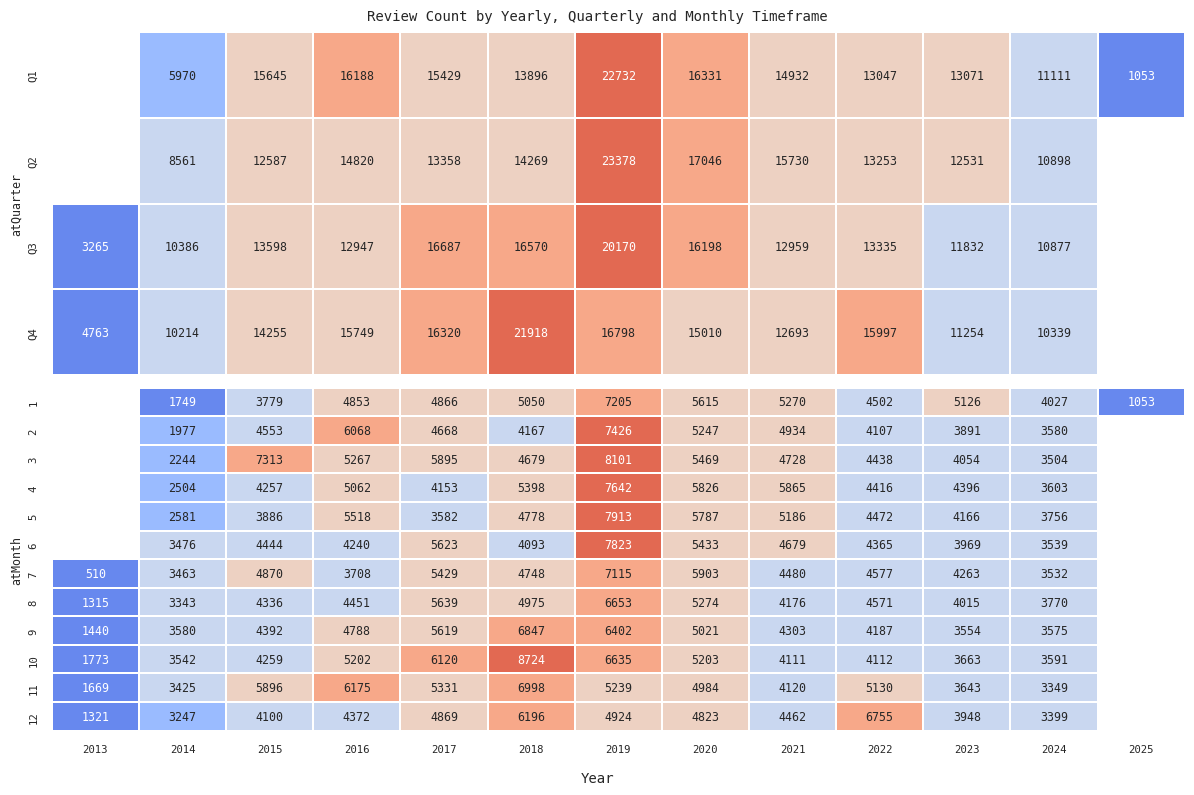

In [14]:
fig,ax=plt.subplots(2,1,figsize=(12,8))

above=sns.heatmap(
  data_processed.groupby(['atQuarter','atYear']).star.size().reset_index().pivot(
    index='atQuarter',columns='atYear',values='star'
  ),
  annot=True,
  cmap=sns.color_palette('coolwarm'),
  linewidth=.1,
  cbar=False,
  fmt='.0f',
  ax=ax[0]
)

below=sns.heatmap(
  data_processed.groupby(['atMonth','atYear']).star.size().reset_index().pivot(
    index='atMonth',columns='atYear',values='star'
  ),
  annot=True,
  cmap=sns.color_palette('coolwarm'),
  linewidth=.1,
  cbar=False,
  fmt='.0f',
  ax=ax[1]
)

above.set_xticks([])
[q.set_xlabel('') for q in (above,below)]
fig.suptitle('Review Count by Yearly, Quarterly and Monthly Timeframe')
fig.supxlabel('Year')
fig.tight_layout()

Text(0.5, 1.0, 'Yearly Count by Mean of Star')

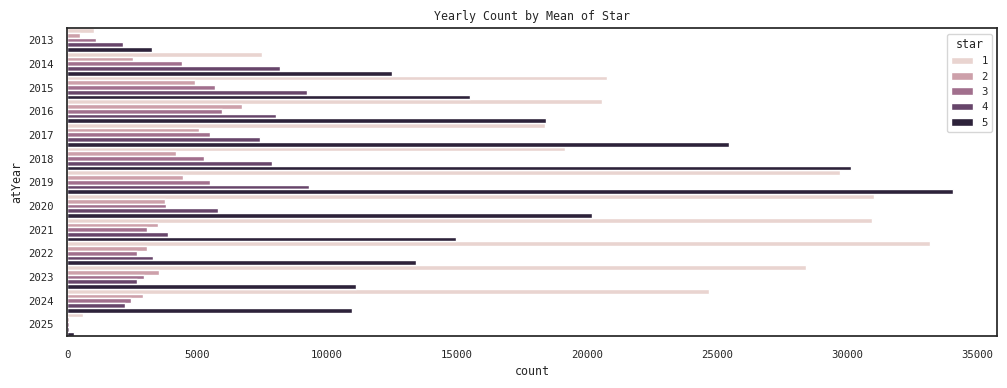

In [16]:
plt.subplots(figsize=(12,4))
star_mean_count_yearly=sns.countplot(data_processed, y='atYear', hue='star', dodge=True, width=1.)
star_mean_count_yearly.set_title('Yearly Count by Mean of Star')

#### Hourly, Quarterly Number of App Rating (Stars)

* There seems to a no quarterly seasonality.
  * Average rating is more likely to be affected by other reasons like algorithm changes, and imbalance of user proportion by massive inflow.
* The users are tend to give bad reviews at the late night, and they're giving good reviews at the morning.
  * It's not hard to assuming the user could encounter unpleasant events at the night, but it's strange that anybody wrote positive reviews at the morning.

In [18]:
data_processed_star=data_processed.query('atYear not in (2013, 2025)').groupby(['atYear','atQuarter','atHourInterval']).star.mean().round(3).reset_index()
data_processed_star.sample(3)

,atYear,atQuarter,atHourInterval,star
107,2017,Q2,9,3.243
43,2015,Q2,9,3.123
117,2017,Q3,15,3.438


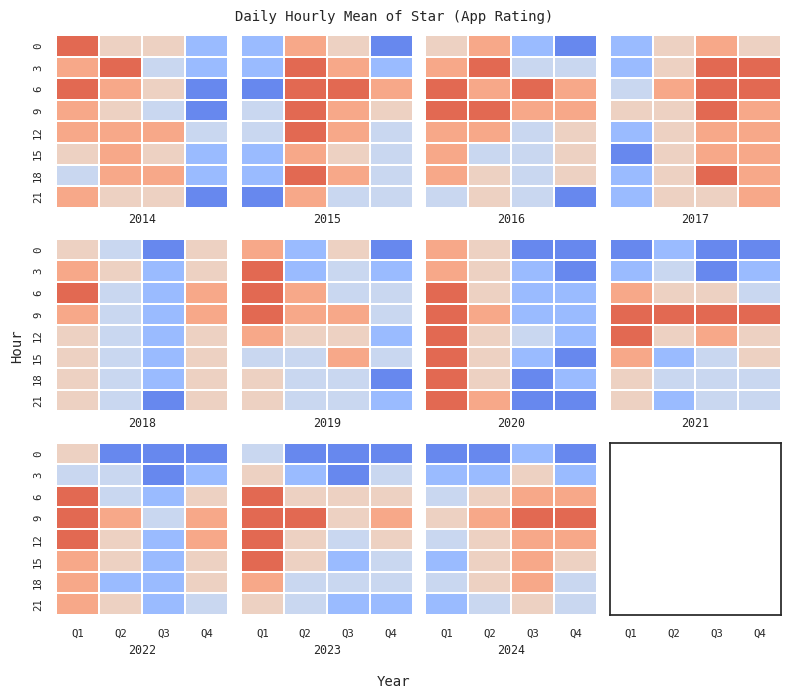

In [19]:
fig,ax=plt.subplots(3,4,sharex=True,sharey=True,figsize=(8,7))

for obj_year in zip(ax.flat,data_processed_star.atYear.unique()):
  for obj_quarter in enumerate([f'q{w}' for w in range(1,5)]):
    hourly_star=sns.heatmap(
      data_processed_star.loc[data_processed_star.atYear==obj_year[1]].pivot(index='atHourInterval',columns='atQuarter',values='star'),
      cmap=sns.color_palette('coolwarm'),
      linewidth=.1,
      cbar=False,
      ax=obj_year[0]
    )
    hourly_star.set_xlabel(f'{obj_year[1]}')
    hourly_star.set_ylabel('')

fig.supxlabel('Year')
fig.supylabel('Hour')
fig.suptitle('Daily Hourly Mean of Star (App Rating)')
fig.tight_layout()


/tmp/ipykernel_332509/800033385.py:4: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  data_processed.melt(


Text(0.5, 0.98, 'Stars By Timeframe')

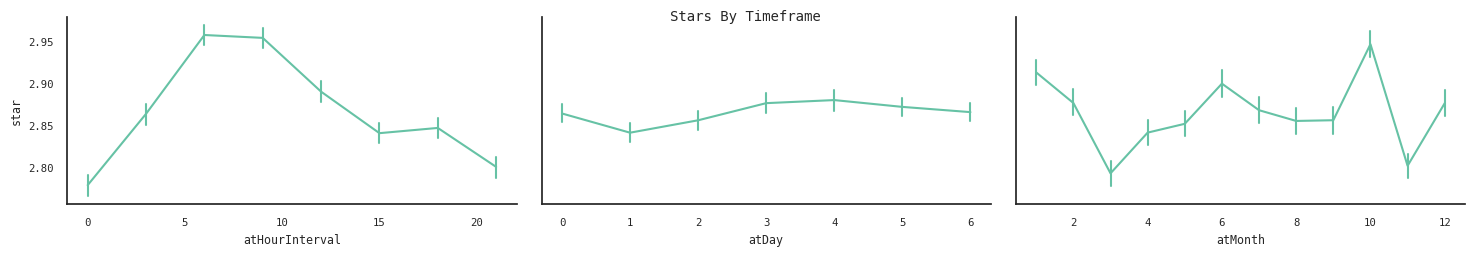

In [22]:
timeframe_list=['atHourInterval', 'atDay', 'atMonth']

star_by_timeframe=sns.PairGrid(
  data_processed.melt(
    timeframe_list,
    'star',
    var_name='Timeframe',
    value_name='star'
  ),
  x_vars=timeframe_list,
  y_vars=['star'],
  aspect=2
)

star_by_timeframe.map(sns.lineplot,err_style='bars')

star_by_timeframe.fig.suptitle('Stars By Timeframe')

In [23]:
star_monthly_daily=data_processed.loc[:, ['atMonth', 'atDay', 'star']]
star_monthly_daily.columns=['Month','Day','Star']
star_monthly_daily=star_monthly_daily.groupby(['Month', 'Day']).Star.mean()
star_monthly_daily.index=star_monthly_daily.index.set_levels(
  star_monthly_daily.index.get_level_values(level=1).map(
  lambda q: {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
  }[q]
  ),level=1,verify_integrity=False)

Text(0.5, 1.0, 'Mean Star Rating by Monthly Day')

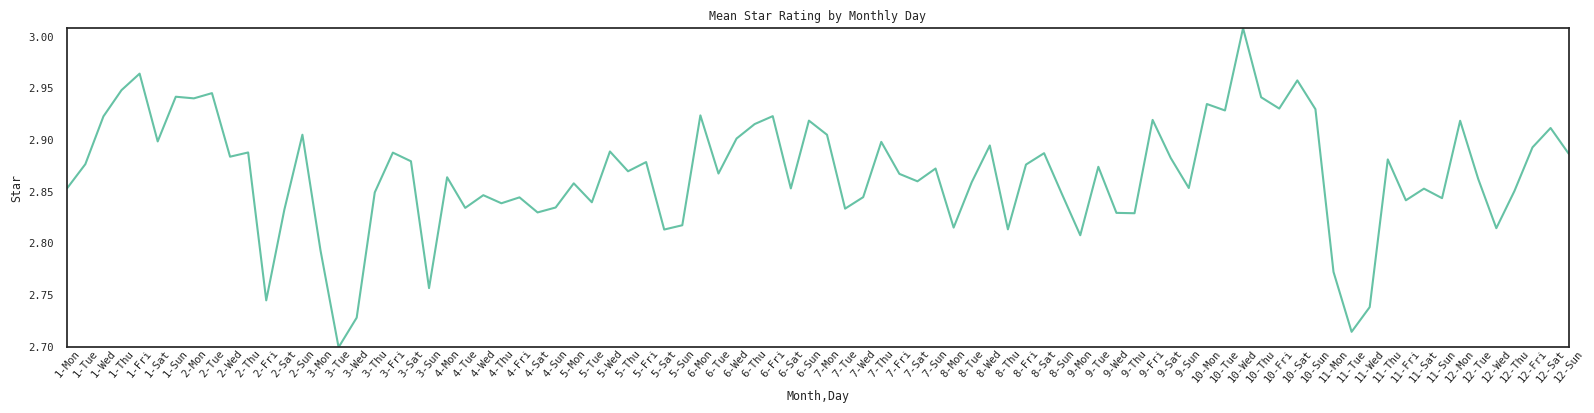

In [24]:
fig,ax=plt.subplots(figsize=(16,4))
star_monthly_daily.plot(ax=ax)
ax.set_xticks(
  range(len(star_monthly_daily.index)),
  [f'{q[0]}-{q[1]}' for q in star_monthly_daily.index],
  rotation=50
)
ax.tick_params(axis='x', pad=-5)
ax.set_ylabel('Star')

plt.margins(0)
plt.tight_layout()

ax.set_title('Mean Star Rating by Monthly Day')

#### Aggregated App Rating by App Version, Year

* Below lineplots show clear downtrends after the major lockdown at March, 2020.
  * The sentiment may be related to vital problems at the time (e.g. increasing jobloss count and revenue discount rate). 
  * More can be known with further info beyond this dataset.

In [22]:
data_processed.loc[:, 'ver'] = data_processed.ver.apply(
  lambda q: q[:q.index('.')] if q.__contains__('.') else q
)
data_processed.sample(3)

,thumb,star,review,ver,at,atYear,atMonth,atHourInterval,atDay,atQuarter
598917,0,5,Good job,3,2014-12-13 03:00:00,2014,12,3,5,Q4
66978,1,1,People! This app is designed to keep you a pay...,14,2023-07-04 09:00:00,2023,7,9,1,Q3
213186,0,1,My app is broken down I can't use any more,11,2020-11-10 09:00:00,2020,11,9,1,Q4


Text(0.5, 0.98, 'Mean of Star, by App Version and Year')

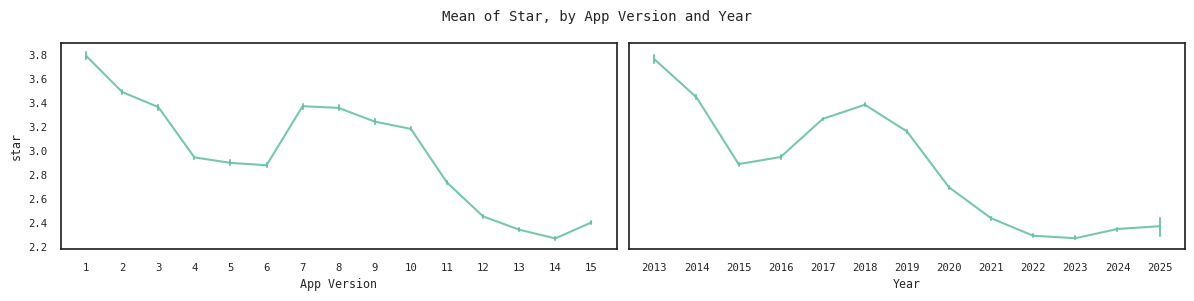

: 

In [26]:
fig,ax=plt.subplots(1,2,figsize=(12,3),layout='tight',sharey=True)

star_by_ver=sns.lineplot(data_processed, x='ver', y='star', n_boot=30, err_style='bars',
  ax=ax[0], **asthetic_constraint)

star_by_year=sns.lineplot(data_processed, x=data_processed.atYear.astype('str'), y='star', n_boot=30, err_style='bars',
  ax=ax[1], **asthetic_constraint)

star_by_ver.set(xlabel='App Version')
star_by_year.set(xlabel='Year')

fig.suptitle('Mean of Star, by App Version and Year')

### Score Star (Review Ratings)

* There's a 'featured review' with an usefulness score on Play Store, to giving higher order for certain reviews.
  * I will take account both thumbs and stars are generating an usefulness score.

In [ ]:
data_processed=data_processed.assign(score=\
  yeojohnson((data_processed.thumb + 1) * (data_processed.star - 2.5))[0].astype('f4')
)
data_processed.sample(3)

,thumb,star,review,ver,at,atYear,atMonth,atHourInterval,atDay,atQuarter,score
272894,0,4,Cool,11,2019-12-10 15:00:00,2019,12,15,1,Q4,1.545396
4632,0,1,i hardly get matches it's a bummer,15,2024-11-29 06:00:00,2024,11,6,4,Q4,-1.456248
214159,0,1,I got banned for no reason. No warnings and no...,11,2020-11-04 09:00:00,2020,11,9,2,Q4,-1.456248


In [24]:
data_processed.groupby('star').score.agg(['mean','median','std']).T

star,1,2,3,4,5
mean,-5.202151,-1.857598,1.525416,3.182238,3.565584
median,-1.456248,-0.493950,0.506146,1.545396,2.609002
std,43.375537,13.718477,16.308869,49.309061,37.154271


### Get Review Text Clusters

* Here, I'm trying to show the review clusters made from mostly vital (decomposed) words of text, and taking out the negative and positive themes, as those are would be a clue for innermost problems of the app.
* What I got was unsatisfying results with gibberish clusters. This is likely caused by no prior preprocesses for short length of words in review texts.
  * Using texts and rating features with longer (words list) length would provide meaningful clustering or topic extraction results.

In [3]:
term_counter=TfidfVectorizer(sublinear_tf=True,dtype=np.float32)

tf=to_darr(
  term_counter.fit_transform(data_processed.review.to_list())
)
tf_compressed=get_svd(tf, n=300, backend='dask')
tf_compressed_thin=tf_compressed[0].rechunk({1: tf_compressed[0].shape[0]})

tf_compressed_thin

dask.array<mul, shape=(639970, 300), dtype=float32, chunksize=(5792, 300), chunktype=numpy.ndarray>

In [ ]:
cluster_count_range=range(3,7)

kmeans_clusterer_options=dict(
  max_iter=30*10 ** 2,
  init='k-means||',
  n_init=30*10 ** 2,
  max_samples_per_batch=(1024 * 32) / 1
)

tf_cluster_groundtruth_input=cp.asarray(
  data_processed.loc[:,['thumb', 'star', 'score']].to_numpy(dtype='f4')
)

tf_cluster_groundtruth=cluster_iterated(
  tf_cluster_groundtruth_input,
  KMeans,
  kmeans_clusterer_options,
  cluster_count_range=cluster_count_range
)

ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=3 
ㅡㅡㅡ Elements: [    43 639476    451] 
ㅡㅡㅡ Fitting Took 1094.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=4 
ㅡㅡㅡ Elements: [    43 638708    143   1076] 
ㅡㅡㅡ Fitting Took 1434.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=5 
ㅡㅡㅡ Elements: [638688      2    143     68   1069] 
ㅡㅡㅡ Fitting Took 3046.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=6 
ㅡㅡㅡ Elements: [638383      2     17    226   1276     66] 
ㅡㅡㅡ Fitting Took 2641.0 s 


In [6]:
tf_cluster=cluster_iterated(
  tf_compressed_thin,
  KMeans,
  kmeans_clusterer_options,
  cluster_count_range=cluster_count_range,
)

ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=3 
ㅡㅡㅡ Elements: [ 17311  21700 600959] 
ㅡㅡㅡ Fitting Took 798.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=4 
ㅡㅡㅡ Elements: [ 46511 209887  22480 361092] 
ㅡㅡㅡ Fitting Took 843.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=5 
ㅡㅡㅡ Elements: [ 57099 386902  22402  18001 155566] 
ㅡㅡㅡ Fitting Took 788.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=6 
ㅡㅡㅡ Elements: [ 10441 292747  20340 251653  20828  43961] 
ㅡㅡㅡ Fitting Took 834.0 s 


In [7]:
kmeans_clusterer_init_options=dict(
  max_iter=30*10 ** 2,
  init='k-means||',
  n_init=30*10 ** 2
)

spectral_clusterer_options=dict(
  affinity='polynomial',
  n_neighbors=int(tf_compressed_thin.shape[0] * .05),
  degree=3,
  n_components=tf_compressed_thin.shape[1],
  persist_embedding=True,
  random_state=1522,
  n_jobs=-1,
  kmeans_params=kmeans_clusterer_init_options
)

tf_cluster_spectral=cluster_iterated(
  tf_compressed_thin,
  SpectralClustering,
  spectral_clusterer_options,
  cluster_count_range=cluster_count_range,
)

ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=3 
ㅡㅡㅡ Elements: [338752 225681  75537] 
ㅡㅡㅡ Fitting Took 17.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=4 
ㅡㅡㅡ Elements: [272582 149229  47859 170300] 
ㅡㅡㅡ Fitting Took 16.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=5 
ㅡㅡㅡ Elements: [136873 134642 105704 250700  12051] 
ㅡㅡㅡ Fitting Took 18.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=6 
ㅡㅡㅡ Elements: [110121 135132 168474  24250 189347  12646] 
ㅡㅡㅡ Fitting Took 18.0 s 


ㅡㅡㅡ Fitting for (param={'perplexity': 15, 'n_iter': 10000, 'learning_rate': 0.1}) 
[W] [12:06:34.673359] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1354.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 30, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [12:29:09.178026] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1355.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 35, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [12:51:44.280405] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


...

ㅡㅡㅡ Took 1368.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 20, 'n_iter': 10000, 'learning_rate': 10}) 
[W] [13:37:14.963464] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1363.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 50, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [13:59:58.519699] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1417.0 s 


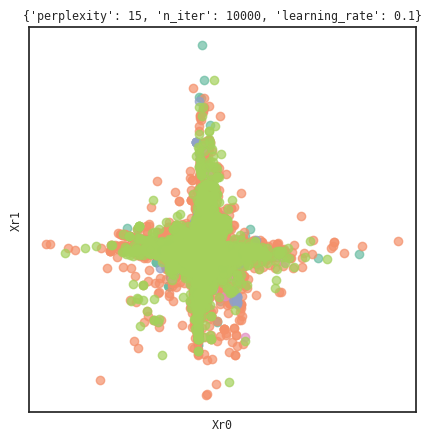

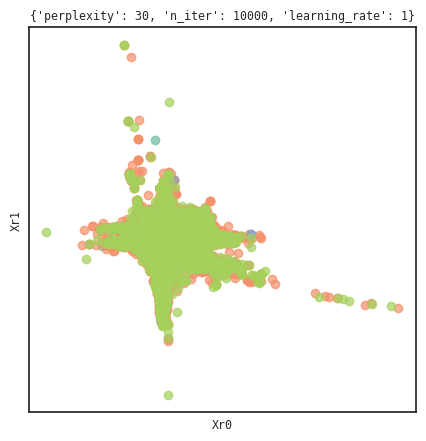

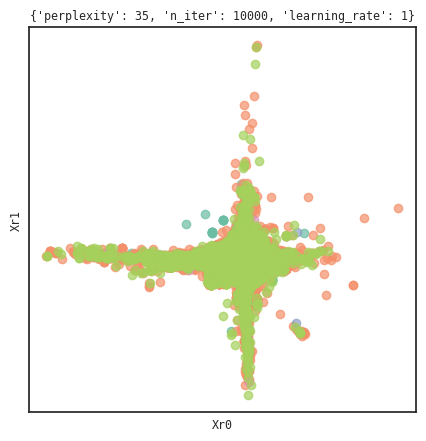

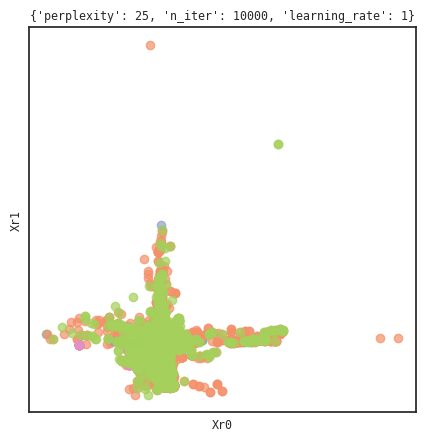

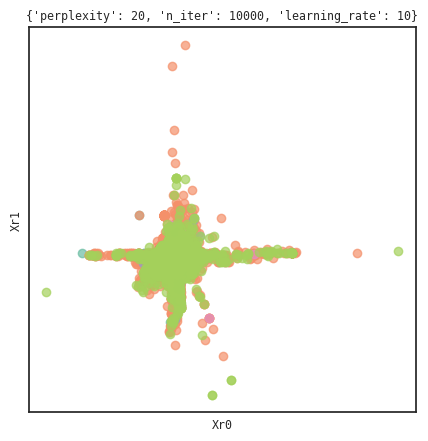

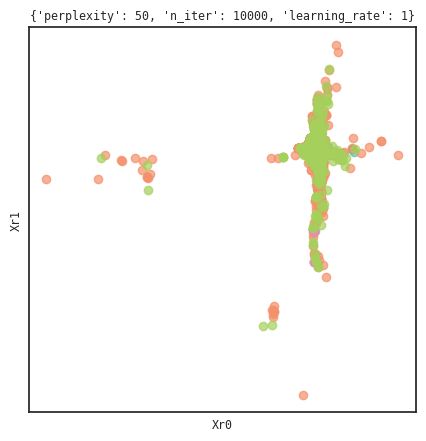

In [4]:
tf_cluster_coordinate_input=tf_compressed_thin.map_blocks(cp.asarray, dtype='f4').compute()

t_clusterer_options=dict(
  perplexity=[5*q for q in range(2,11)],
  n_iter=[10**q for q in range(4,5)],
  learning_rate=[10**q for q in range(-1,2)],
)

tf_cluster_label_normal=data_processed.reviewType.to_numpy(dtype='u4')

tf_cluster_coordinate_normal=cluster_aggregated(
  tf_cluster_coordinate_input,
  tf_cluster_label_normal,
  clusterer_options=t_clusterer_options,
  clusterer_options_size=6,
)